In [2]:
from fastai.vision.all import *

In [3]:
torch.cuda.is_available()

True

In [4]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [5]:
from make import load

hard = load('.spec/train/Hard')
slip = load('.spec/train/Slip_Trip')
controlled = load('.spec/train/Controlled')

In [6]:
path = Path('.spec/')

In [119]:
test = np.load("./.spec/train/Hard/labels.npy")

In [170]:
import os


def get_spectrograms(path:Path):
    result_arr = []
    labels_arr = []
    
    train_folders = os.listdir(path/"train")
    test_folders = os.listdir(path/"test")

    for folder in train_folders:
        train_files = os.listdir(path/"train"/folder)
        
        for file in train_files:
            arr = np.load(path/"train"/folder/file)
            labels_arr.append(folder)
            result_arr.append(arr)
            
    return result_arr, labels_arr

all_spectrograms, all_labels = get_spectrograms(Path(".spec/"))



In [171]:
len(all_spectrograms)

300

In [172]:
good_mask = [isinstance(a, np.ndarray) and a.ndim == 3 for a in all_spectrograms]
all_spectrograms = [a for a,m in zip(all_spectrograms, good_mask) if m]
all_labels       = [l for l,m in zip(all_labels,       good_mask) if m]

In [173]:
len(all_spectrograms)

300

In [174]:
print(f'Initial shape of a spectrogram: ', all_spectrograms[0].shape)

ch, freq_bins, time_bins = all_spectrograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx, time_bins)
print(f'Final shape: {final_shape}')


Initial shape of a spectrogram:  (4, 257, 7)
Final shape: (4, 72, 7)


In [184]:
# constants you can tweak once
FLOOR_DB   = -80.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 3
EPS = 1e-12
RESIZE_HW  = None

In [199]:
def get_x(i):
    arr = all_spectrograms[i]                 # expected (C, F, T)

    # Ensure 3D
    if arr.ndim == 2:                         # (F, T) -> (1, F, T)
        arr = arr[None, ...]
    if arr.ndim != 3:
        raise ValueError(f"Expected (C,F,T), got {arr.shape} at index {i}")

    # Enforce consistent channel count to avoid 4 vs 3 errors
    C = arr.shape[0]
    if TARGET_CH is not None:
        if C < TARGET_CH:                     # pad/repeat to reach TARGET_CH
            reps = (TARGET_CH + C - 1) // C
            arr = np.tile(arr, (reps, 1, 1))[:TARGET_CH]
        elif C > TARGET_CH:                   # drop extra channels (keep last ones)
            arr = arr[-TARGET_CH:, ...]

    # --- Normalization to dB and [0,1] ---
    arr = arr.astype(np.float32)
    arr_db = 10.0 * np.log10(np.maximum(arr, EPS))  # guard against <=0
    arr_db = np.clip(arr_db, FLOOR_DB, 0.0)
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)      # [0,1]

    # Flip spectrogram (same as your original)
    arr_01 = arr_01[:, ::-1, :].copy()

    # To tensor; keep size unless RESIZE_HW is set
    t = torch.from_numpy(arr_01).float().unsqueeze(0)  # (1, C, F, T)
    if TARGET_HW is not None:
        t = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)

    return TensorImage(t.squeeze(0).contiguous())      # (C, F, T) or (C, H, W) if resized

def get_y(i):
    return all_labels[i]


In [128]:
from pathlib import Path

def build_items(path: Path):
    items = []  # list of (spec_path, label)
    for folder in sorted(os.listdir(path/"train")):
        folder_path = path/"train"/folder
        if not folder_path.is_dir(): 
            continue
        lbl_path = folder_path/"labels.npy"
        if not lbl_path.exists():
            continue

        labels = np.load(lbl_path)
        spec_files = sorted(
            f for f in os.listdir(folder_path)
            if f.endswith(".npy") and f != "labels.npy"
        )

        n = min(len(labels), len(spec_files))
        for f, lab in zip(spec_files[:n], labels[:n]):
            items.append((folder_path/f, lab))
    return items


In [129]:
items = build_items(Path(".spec/"))
print("Total items:", len(items))
print("Example:", items[0])

Total items: 6
Example: (Path('.spec/train/Controlled/Session_10_rel_time0.npy'), np.str_('Controlled'))


In [218]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [219]:
len(all_spectrograms)

300

In [242]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=min(16, len(all_spectrograms)))

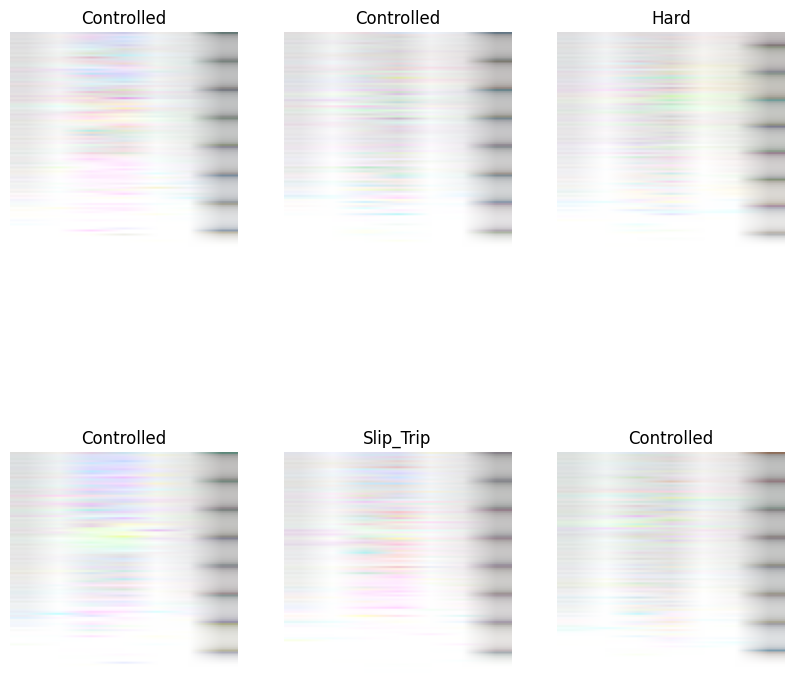

In [243]:
dls.show_batch(max_n=6, figsize=(10,10))

In [244]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [256]:
learner = vision_learner(dls, resnet34, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

In [257]:
learner.summary()

Sequential (Input shape: 16 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     16 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

SuggestedLRs(valley=0.001737800776027143, slide=0.00363078061491251, steep=6.309573450380412e-07)

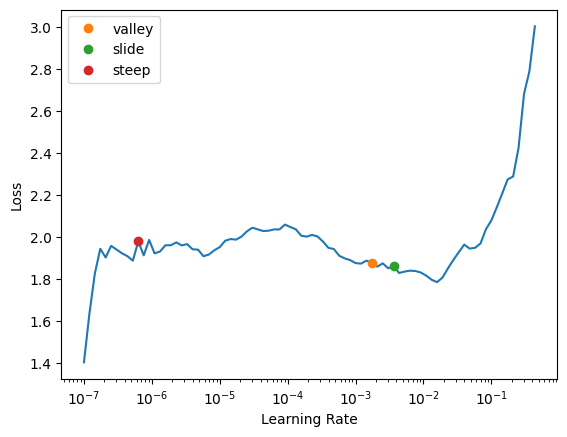

In [258]:
learner.lr_find(suggest_funcs=(valley,slide,steep))

In [259]:
learner.fit_one_cycle(25, 1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,1.931922,1.415585,0.283333,00:00
1,1.511527,1.602392,0.416667,00:00
2,1.306497,2.378417,0.400000,00:00
3,1.349533,2.186652,0.566667,00:00
4,1.403600,2.858507,0.416667,00:00
5,1.327567,1.817318,0.400000,00:00
6,1.252328,1.096158,0.583333,00:00
7,1.222273,2.006510,0.583333,00:00
8,1.114968,1.577263,0.600000,00:00
9,1.008205,1.863350,0.533333,00:00


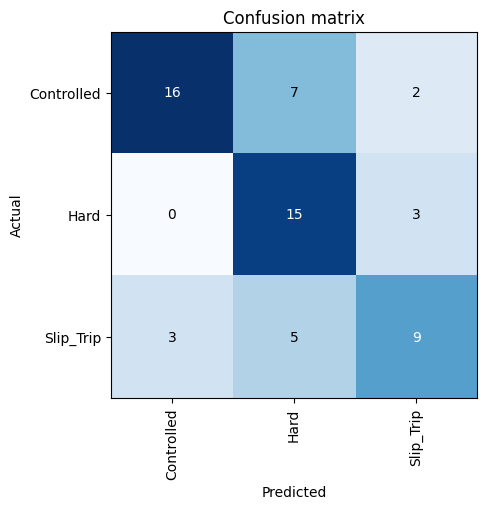

In [260]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

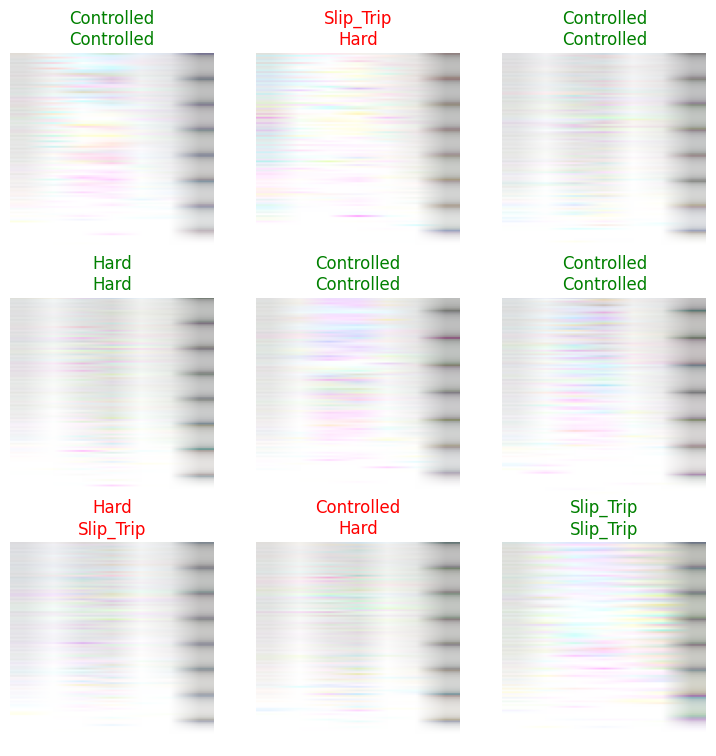

In [261]:
learner.show_results()